#####**Observação:** É necessário carregar todos resultados do tas2.*csvs, e benchmark do experiment 2

#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)


---
7.   **Experimento 2 -  Adição do Dask Modin ao benchmark**

O DaskModin combina duas camadas:

- Modin → API Pandas transparente
- Dask → motor de execução baseado em task graph

>7.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados:



In [27]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

!pip install dask[complete] pyarrow          # Dask
                           # Profiling multi-thread
!pip install modin[dask]

print("OK.")

OK.


Iniciando a leitura com algumas importações necessárias:

In [28]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:35


In [29]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

# --- Dask ---
try:
    import dask.dataframe as dd
    import dask
    print(f"Dask        : {dask.__version__}")
    DASK_AVAILABLE = True
except ImportError:
    print("Dask não disponível")
    DASK_AVAILABLE = False
try:
    # Muda o backend antes de importar modin novamente
    os.environ["MODIN_ENGINE"] = "dask"
    import importlib
    import modin
    importlib.reload(modin)                  # Recarrega com novo backend
    import modin.pandas as mpd
    print(f" Modin       : {modin.__version__}")
    MODIN_AVAILABLE = True
except ImportError:
    print(" Modin não disponível (pip install modin[ray])")
    MODIN_AVAILABLE = False


# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

Dask        : 2026.3.0
 Modin       : 0.37.1
 Scikit-learn: 1.6.1


In [30]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 2      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 2


In [31]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

yellow_tripdata_2026-02.parquet
yellow_tripdata_2026-01.parquet


In [32]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [33]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [34]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


 Já existe: yellow_tripdata_2026-01.parquet (64.2 MB)
 Já existe: yellow_tripdata_2026-02.parquet (58.7 MB)
Processo de download concluído!


7.2   **Início das Operações**


In [35]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [36]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [37]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed


>7.2.1  **Task 1 — Leitura dos Dados (*Reading*)**


In [38]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet


In [39]:
# ── Task DaskModin ──
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start = time.perf_counter()
    time.perf_counter()
    df_modin = mpd.read_parquet(caminho)
    t_modin_load = time.perf_counter() - start
    print(f"DaskModin: {len(df_modin):,} linhas em {t_modin_load:.2f}s")
    resultados.append(('Task 1 - Leitura', 'DaskModin', round(t_modin_load, 4)))
else:
    print("  Modin não disponível")

DaskModin: 7,124,755 linhas em 7.45s


In [40]:
df_modin.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


>7.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**


**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.

In [41]:
# ── Task 2A: Value Counts ─────
# Conta quantas viagens ocorreram por tipo de fornecedor.

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)


# DaskModin
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start_m2 = time.time()
    counts_modin = df_modin['VendorID'].value_counts()
    t_m_vc = time.time() - start_m2
    print(f"\nTempo Value Counts (DaskModin)  : {t_m_vc:.4f}s  [ADICIONADO]")
    print(counts_modin)
    resultados.append(('Task 2a - Value Counts', 'DaskModin', round(t_m_vc, 4)))

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────

Tempo Value Counts (DaskModin)  : 0.7170s  [ADICIONADO]
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.

In [42]:
# ── Task 2B: GroupBy Mean  ─────
# Calcula a tarifa média (fare_amount) por tipo de fornecedor.

print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)

# DaskModin
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start_m3 = time.time()
    mean_modin = df_modin.groupby('VendorID')['fare_amount'].mean()
    t_m_gb = time.time() - start_m3
    print(f"\nTempo GroupBy (DaskModin)  : {t_m_gb:.4f}s ")
    print(mean_modin)
    resultados.append(('Task 2b - GroupBy', 'DaskModin', round(t_m_gb, 4)))


─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────

Tempo GroupBy (DaskModin)  : 0.4596s 
VendorID
1    20.334299
2    21.513850
6     2.746568
7    16.559094
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.

In [43]:
# ── Task 2C: Filtragem Complexa  ─
# Filtra viagens com mais de 2 passageiros e calcula distância média.

print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)


# DaskModin
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start_m4 = time.time()
    filtro_m = df_modin[df_modin['passenger_count'] > 2]['trip_distance'].mean()
    t_m_fi = time.time() - start_m4
    print(f"Tempo Filtro (DaskModin)  : {t_m_fi:.4f}s  |  Distância média: {filtro_m:.2f} milhas")
    resultados.append(('Task 2c - Filtragem', 'DaskModin', round(t_m_fi, 4)))

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────
Tempo Filtro (DaskModin)  : 0.7517s  |  Distância média: 3.72 milhas


 ---
>7.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização.

In [44]:
# ============================================================
# PREPARAÇÃO GLOBAL (DaskMODIN)
# ============================================================

url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    df_zones_m = mpd.read_csv(url_zonas)
    df_zones_m = df_zones_m.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_m = mpd.DataFrame({
        'PULocationID': list(range(1, 266)),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# Parquets (Modin consegue ler diretamente múltiplos ficheiros)
caminhos = [str(f) for f in sorted(caminho.glob("*.parquet"))]

df_jan = mpd.read_parquet(caminhos[0])
df_fev = mpd.read_parquet(caminhos[1]) if len(caminhos) > 1 else df_jan

# Dataset combinado
df_viagens_m = mpd.concat([df_jan, df_fev], axis=0)

In [45]:
# ============================================================
# MODIN
# ============================================================

start_m = time.time()

df_final_m = df_viagens_m.merge(
    df_zones_m,
    on='PULocationID',
    how='left'
)

_ = df_final_m.head(1)

t_m_join = time.time() - start_m

print(f"Tempo Join (DaskModin) : {t_m_join:.4f}s")

display(
    df_final_m[
        ['PULocationID', 'Zone', 'fare_amount']
    ].head(3)
)

resultados.append((
    'Task 3 - Join',
    'DaskModin',
    round(t_m_join, 4)
))

Tempo Join (DaskModin) : 17.2457s


,PULocationID,Zone,fare_amount
0,239,Upper West Side South,7.2
1,163,Midtown North,7.9
2,43,Central Park,10.7



---
>7.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

In [46]:
# ── Task 4: Cálculo  ───────────
print("─" * 45)
print("Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)")
print("─" * 45)

# DaskModin
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start = time.time()
    df_modin['tip_per_passenger'] = df_modin['tip_amount'] / df_modin['passenger_count'].replace(0, float('nan'))
    t_m_calc = time.time() - start
    print(f"Tempo Cálculo (DaskModin)   : {t_m_calc:.4f}s  ")
    resultados.append(('Task 4 - Cálculo', 'DaskModin', round(t_m_calc, 4)))

─────────────────────────────────────────────
Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)
─────────────────────────────────────────────
Tempo Cálculo (DaskModin)   : 0.2273s  


---
>7.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

In [47]:
# ── Task 5: Escrita  ───────────

print("─" * 45)
print("Task 5 — ESCRITA EM PARQUET")
print("─" * 45)


# DaskModin
if MODIN_AVAILABLE and DASK_AVAILABLE:
    start = time.time()
    df_modin.to_parquet('./resultado_daskmodin.parquet')
    t_m_write = time.time() - start
    print(f"Tempo Escrita (DaskModin)   : {t_m_write:.4f}s ")
    resultados.append(('Task 5 - Escrita', 'DaskModin', round(t_m_write, 4)))

─────────────────────────────────────────────
Task 5 — ESCRITA EM PARQUET
─────────────────────────────────────────────
Tempo Escrita (DaskModin)   : 7.8524s 


---
8   **Predição - Experimento**

>8.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>8.2 **Resultado e Análise**

In [48]:
tabela_pivot = pd.read_csv("benchmark_pivotmodin.csv", index_col=0)
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,Vencedor
Operação,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,Pandas
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,Pandas
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,Koalas
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,Pandas
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,Koalas
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,Pandas
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,Pandas


In [49]:
tabela_pivot.loc['Task 1 - Leitura', 'DaskModin'] = t_modin_load
tabela_pivot.loc['Task 2a - Value Counts', 'DaskModin'] = t_m_vc
tabela_pivot.loc['Task 2b - GroupBy', 'DaskModin'] = t_m_gb
tabela_pivot.loc['Task 2c - Filtragem', 'DaskModin'] = t_m_fi
tabela_pivot.loc['Task 3 - Join', 'DaskModin'] = t_m_join
tabela_pivot.loc['Task 4 - Cálculo', 'DaskModin'] = t_m_calc
tabela_pivot.loc['Task 5 - Escrita', 'DaskModin'] = t_m_write

In [50]:
# ============================================================
# Ratio DaskModin/Pandas
# ============================================================

if 'DaskModin' in tabela_pivot.columns and 'Pandas' in tabela_pivot.columns:
    tabela_pivot['Ratio DaskModin/Pandas'] = (
        tabela_pivot['DaskModin'] / tabela_pivot['Pandas']
    ).round(2)


# ============================================================
# mover  Vencedor para última coluna
# ============================================================

col_vencedor = tabela_pivot.pop(' Vencedor')
tabela_pivot[' Vencedor'] = col_vencedor

In [51]:
def winner(row):
    # colunas que NÃO podem entrar no cálculo
    ignore_cols = [' Vencedor'] + [c for c in row.index if 'Ratio' in c]

    vals = {
        k: v for k, v in row.items()
        if k not in ignore_cols
        and isinstance(v, (int, float))
        and pd.notna(v)
    }

    return min(vals, key=vals.get) if vals else '?'

tabela_pivot[' Vencedor'] = tabela_pivot.apply(winner, axis=1)
tabela_pivot.to_csv("benchmark_pivotdaskmodin.csv")
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,DaskModin,Ratio DaskModin/Pandas,Vencedor
Operação,,,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,7.451377,2.77,Pandas
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,0.716981,8.54,Pandas
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,0.459600,1.89,Koalas
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,0.751710,4.38,Pandas
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,17.245725,7.38,Koalas
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,0.227336,2.24,Pandas
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,7.852370,1.18,Pandas


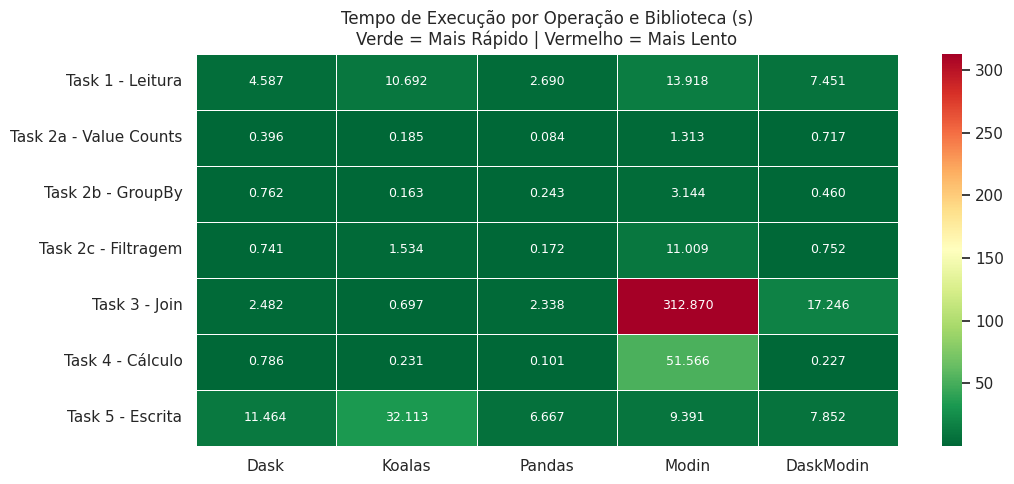

 Guardado: heatmap_exp1daskmodin.png


In [52]:
# ── Heatmap Visual  ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1daskmodin.png', dpi=150)
plt.show()
print(" Guardado: heatmap_exp1daskmodin.png")

O DaskModin (Modin com backend Dask) apresenta um comportamento intermédio ao longo de todas as tarefas, funcionando como uma camada de abstração sobre o motor de execução distribuída do Dask.

Apesar de usar Dask como backend:

- não elimina o overhead do Modin
- adiciona complexidade adicional ao pipeline
- perde vantagem face a Dask direto em várias tasks

**Próximo Notebook:**

 3-experimento_JobLib.ipynb -  Uso de Joblib
